In [15]:
import pandas as pd
import numpy as np

### 1.Data Clean

In [16]:
url="https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
raw_data = pd.read_csv(url)
raw_data.shape

(7214, 53)

In [17]:
### data selection
numeric_vars = ["age", "priors_count", "days_b_screening_arrest","decile_score"]
datetime_vars = ["c_jail_in", "c_jail_out"]
select_data = ['age', 'c_charge_degree', 'race', 'age_cat',
                    'score_text', 'sex', 'priors_count',
                    'days_b_screening_arrest', 'decile_score', 'is_recid',
                    'two_year_recid', 'c_jail_in', 'c_jail_out']

df = raw_data[select_data].copy()
### filter and clean data
df = df[df['days_b_screening_arrest'].between(-30,30)]
df = df[df['is_recid']!=-1]
df = df[df['c_charge_degree']!='0']
df = df[df['score_text'] != "N/A"]

### Type conversions
for col in datetime_vars:
    df[col] = pd.to_datetime(
        df[col],
        format="%Y-%m-%d %H:%M:%S",
        utc=True,
        errors="coerce"
    )

for i in df.columns:
    if i not in numeric_vars + datetime_vars:
        df[i]=df[i].astype('category')

### factor feature
df['crime_factor'] = df["c_charge_degree"].astype("category")

#age_factor, reference 25-45
df["age_factor"] = pd.Categorical(
    df["age_cat"],
    categories=["25 - 45", "Greater than 45", "Less than 25"]
)

#race_factor, reference Caucasian
race_categories = list(df["race"].cat.categories)
race_categories = ["Caucasian"] + [c for c in race_categories if c != "Caucasian"]
df["race_factor"] = pd.Categorical(df["race"], categories=race_categories)

#gender_factor, reference male
df["gender_factor"] = pd.Categorical(df["sex"], categories=["Male", "Female"])

#score_factor
df["score_factor"] = pd.Categorical(
    np.where(df["score_text"] == "Low", "LowScore", "HighScore"),
    categories=["LowScore", "HighScore"]
)
# 1 = HighScore, 0 = LowScore
df["score_high"] = (df["score_factor"] == "HighScore").astype(int)

print("Number of rows after filtering:", len(df))
df.head()

Number of rows after filtering: 6172


,age,c_charge_degree,race,age_cat,score_text,sex,priors_count,days_b_screening_arrest,decile_score,is_recid,two_year_recid,c_jail_in,c_jail_out,crime_factor,age_factor,race_factor,gender_factor,score_factor,score_high
0,69,F,Other,Greater than 45,Low,Male,0,-1.0,1,0,0,2013-08-13 06:03:42+00:00,2013-08-14 05:41:20+00:00,F,Greater than 45,Other,Male,LowScore,0
1,34,F,African-American,25 - 45,Low,Male,0,-1.0,3,1,1,2013-01-26 03:45:27+00:00,2013-02-05 05:36:53+00:00,F,25 - 45,African-American,Male,LowScore,0
2,24,F,African-American,Less than 25,Low,Male,4,-1.0,4,1,1,2013-04-13 04:58:34+00:00,2013-04-14 07:02:04+00:00,F,Less than 25,African-American,Male,LowScore,0
5,44,M,Other,25 - 45,Low,Male,0,0.0,1,0,0,2013-11-30 04:50:18+00:00,2013-12-01 12:28:56+00:00,M,25 - 45,Other,Male,LowScore,0
6,41,F,Caucasian,25 - 45,Medium,Male,14,-1.0,6,1,1,2014-02-18 05:08:24+00:00,2014-02-24 12:18:30+00:00,F,25 - 45,Caucasian,Male,HighScore,1


## 2. Train/Test Split

Next, define the feature matrix `X` and the target variable `y`, then split the data into training and test sets.

The selected features include:
- gender
- age category
- race
- prior offenses
- charge type
- two-year recidivism

The target is `score_high`, which represents whether the COMPAS score is classified as high risk.

In [18]:
# Step 0 — Train / test split
from sklearn.model_selection import train_test_split

features = [
    "gender_factor",
    "age_factor",
    "race_factor",
    "priors_count",
    "crime_factor",
    "two_year_recid"
]

target = "score_high"

X = df[features]
y = df[target].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(type(y_train), type(y_test))

Train: (4937, 6), Test: (1235, 6)
<class 'pandas.core.series.Series'> <class 'pandas.core.series.Series'>


## 3. Model Training

In [19]:
# Step 1 — Fit logistic regression and gradient-boosted tree

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

numeric_vars = ["priors_count", "two_year_recid"]
categorical_vars = ["gender_factor", "age_factor", "race_factor", "crime_factor"]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_vars),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_vars),
])

# Logistic regression
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

lr_pipeline.fit(X_train, y_train)

# Gradient-boosted tree
gbt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(
        n_estimators=200,
        max_depth=4,
        random_state=42
    ))
])

gbt_pipeline.fit(X_train, y_train)

print("Both models fitted successfully.")

Both models fitted successfully.


## 4. Performance Comparison by Race

In [20]:
# Step 2 — Compare model performance by race

import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score

def group_metrics(pipeline, X, y, group_col="race_factor"):
    results = []
    X_ = X.copy()
    X_["actual"] = y.values
    X_["pred"] = pipeline.predict(X)
    X_["pred_prob"] = pipeline.predict_proba(X)[:, 1]

    for group, gdf in X_.groupby(group_col):
        tn, fp, fn, tp = confusion_matrix(
            gdf["actual"], gdf["pred"], labels=[0, 1]
        ).ravel()

        results.append({
            "race": group,
            "n": len(gdf),
            "accuracy": round(accuracy_score(gdf["actual"], gdf["pred"]), 3),
            "FPR": round(fp / (fp + tn), 3) if (fp + tn) > 0 else None,
            "FNR": round(fn / (fn + tp), 3) if (fn + tp) > 0 else None,
            "AUC": round(roc_auc_score(gdf["actual"], gdf["pred_prob"]), 3)
                  if gdf["actual"].nunique() > 1 else None,
        })

    return pd.DataFrame(results).sort_values("n", ascending=False)

print("Logistic Regression")
print(group_metrics(lr_pipeline, X_test, y_test, group_col="race_factor"))

print("\nGradient-Boosted Tree")
print(group_metrics(gbt_pipeline, X_test, y_test, group_col="race_factor"))

Logistic Regression
               race    n  accuracy    FPR    FNR    AUC
1  African-American  634     0.737  0.387  0.177  0.820
0         Caucasian  412     0.750  0.109  0.562  0.794
3          Hispanic  108     0.824  0.063  0.483  0.831
5             Other   71     0.803  0.019  0.765  0.852
2             Asian    8     0.750  0.000  1.000  0.667
4   Native American    2     0.500  1.000  0.000  1.000

Gradient-Boosted Tree


/tmp/ipykernel_16149/1743071522.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group, gdf in X_.groupby(group_col):
/tmp/ipykernel_16149/1743071522.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group, gdf in X_.groupby(group_col):


               race    n  accuracy    FPR    FNR    AUC
1  African-American  634     0.708  0.360  0.244  0.808
0         Caucasian  412     0.784  0.099  0.477  0.791
3          Hispanic  108     0.815  0.089  0.448  0.833
5             Other   71     0.845  0.019  0.588  0.846
2             Asian    8     0.625  0.167  1.000  0.667
4   Native American    2     0.500  1.000  0.000  1.000


In [21]:
!pip install lime

## 5. Selecting Four Focal Individuals

In [22]:

X_test_prob = gbt_pipeline.predict_proba(X_test)[:, 1]

X_test_copy = X_test.copy()
X_test_copy["pred_prob"] = X_test_prob

black_group = X_test_copy[
    X_test_copy["race_factor"] == "African-American"
].sort_values("pred_prob")

white_group = X_test_copy[
    X_test_copy["race_factor"] == "Caucasian"
].sort_values("pred_prob")

black_low_idx = black_group.index[0]
black_high_idx = black_group.index[-1]

white_low_idx = white_group.index[0]
white_high_idx = white_group.index[-1]

selected_cases = [
    ("Black lowest-risk", black_low_idx),
    ("Black highest-risk", black_high_idx),
    ("White lowest-risk", white_low_idx),
    ("White highest-risk", white_high_idx),
]

for label, idx in selected_cases:
    print(label)
    print(X_test.loc[[idx]])
    print("Predicted probability:", X_test_copy.loc[idx, "pred_prob"])
    print("-" * 60)

Black lowest-risk
     gender_factor       age_factor       race_factor  priors_count  \
4008        Female  Greater than 45  African-American             0   

     crime_factor two_year_recid  
4008            M              0  
Predicted probability: 0.020935162721090007
------------------------------------------------------------
Black highest-risk
     gender_factor age_factor       race_factor  priors_count crime_factor  \
5311        Female    25 - 45  African-American            16            F   

     two_year_recid  
5311              0  
Predicted probability: 0.9993895704998867
------------------------------------------------------------
White lowest-risk
     gender_factor       age_factor race_factor  priors_count crime_factor  \
2517        Female  Greater than 45   Caucasian             0            M   

     two_year_recid  
2517              0  
Predicted probability: 0.01726947659728164
------------------------------------------------------------
White highest-risk

In [23]:
from lime.lime_tabular import LimeTabularExplainer

X_train_enc = preprocessor.fit_transform(X_train)

explainer = LimeTabularExplainer(
    training_data=X_train_enc.toarray() if hasattr(X_train_enc, "toarray") else X_train_enc,
    feature_names=(
        numeric_vars +
        list(
            preprocessor
            .named_transformers_["cat"]
            .get_feature_names_out(categorical_vars)
        )
    ),
    class_names=["Low Score", "High Score"],
    mode="classification",
    discretize_continuous=True,
    random_state=42
)

lime_results = {}

for label, idx in selected_cases:
    row_enc = preprocessor.transform(X_test.loc[[idx]])
    row_arr = row_enc.toarray()[0] if hasattr(row_enc, "toarray") else row_enc[0]

    exp = explainer.explain_instance(
        data_row=row_arr,
        predict_fn=gbt_pipeline["classifier"].predict_proba,
        num_features=6
    )

    lime_results[label] = exp.as_list()

    print(f"\nLIME: {label}")
    print(f"Predicted probability: {X_test_copy.loc[idx, 'pred_prob']:.3f}")
    for feat, weight in exp.as_list():
        print(f"{feat:<45} {weight:+.4f}")


LIME: Black lowest-risk
Predicted probability: 0.021
age_factor_Less than 25 <= 0.00               -0.3577
age_factor_Greater than 45 > 0.00             -0.2213
0.00 < race_factor_African-American <= 1.00   +0.0971
two_year_recid <= -0.92                       -0.0926
race_factor_Hispanic <= 0.00                  +0.0906
priors_count <= -0.68                         -0.0623

LIME: Black highest-risk
Predicted probability: 0.999
race_factor_Native American <= 0.00           -0.4301
priors_count > 0.17                           +0.3839
age_factor_Less than 25 <= 0.00               -0.3482
age_factor_Greater than 45 <= 0.00            +0.2226
0.00 < race_factor_African-American <= 1.00   +0.1052
two_year_recid <= -0.92                       -0.0875

LIME: White lowest-risk
Predicted probability: 0.017
age_factor_Less than 25 <= 0.00               -0.3520
age_factor_Greater than 45 > 0.00             -0.2165
race_factor_African-American <= 0.00          -0.1064
two_year_recid <= -0.92    

LIME vs. SHAP Comparison

LIME and SHAP agree that priors_count and recidivism-related information are important drivers of the prediction. They also agree that low-risk individuals usually have fewer strong risk signals. However, they do not always rank features in the same order, and LIME sometimes gives more weight to local categorical indicators. This divergence matters for governance because one explanation method alone should not be treated as final proof of fairness or correctness.

## 7. SHAP Explanations

SHAP Interpretation

The SHAP beeswarm plot shows that the model is mainly driven by priors_count, two_year_recid, and age-related features. The waterfall plots for the four focal defendants show that high-risk predictions are pushed up mostly by stronger criminal-history signals, while low-risk predictions are pushed down by fewer priors, older age, and no recidivism. Overall, the model seems to rely most heavily on criminal-history information.

 93%|=================== | 1154/1235 [00:13<00:00]       

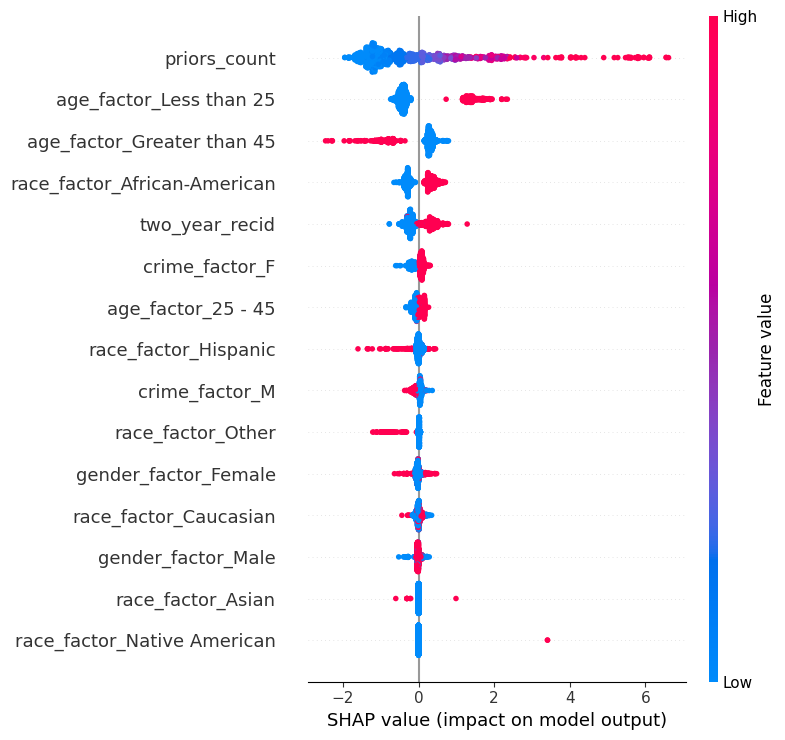

In [24]:
import shap
import matplotlib.pyplot as plt

X_test_enc = preprocessor.transform(X_test)
X_test_enc_dense = X_test_enc.toarray() if hasattr(X_test_enc, "toarray") else X_test_enc

feat_names = (
    numeric_vars +
    list(
        preprocessor
        .named_transformers_["cat"]
        .get_feature_names_out(categorical_vars)
    )
)

explainer_shap = shap.Explainer(
    gbt_pipeline["classifier"],
    X_test_enc_dense
)

shap_values = explainer_shap(X_test_enc_dense, check_additivity=False)


shap.summary_plot(shap_values, X_test_enc_dense, feature_names=feat_names)

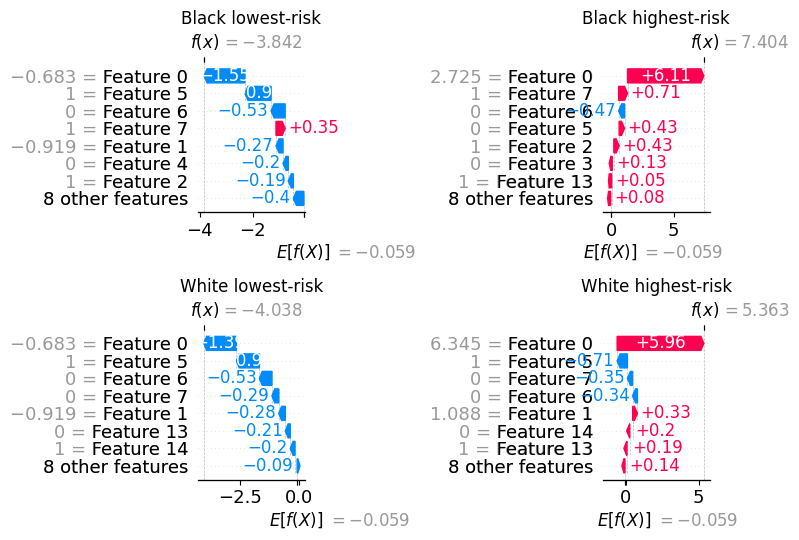

In [25]:
case_locs = [(label, X_test.index.get_loc(idx)) for label, idx in selected_cases]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, (label, loc) in zip(axes, case_locs):
    plt.sca(ax)
    shap.waterfall_plot(shap_values[loc], max_display=8, show=False)
    ax.set_title(label)

plt.tight_layout()
plt.show()

In [26]:
!pip install dice-ml

## 8. Counterfactual Explanations with DiCE

 Counterfactual Interpretation

The counterfactual results show that many predictions can be flipped by changing a small number of mutable features, especially priors_count and sometimes crime_factor. I restricted the search to mutable features only. No accepted counterfactual required changing race or sex, so no immutable features were used in the final recourse examples.

In [27]:
import dice_ml
from dice_ml import Dice
import pandas as pd

dice_train_df = pd.concat(
    [X_train, pd.DataFrame({target: y_train})],
    axis=1
)

dice_data = dice_ml.Data(
    dataframe=dice_train_df,
    continuous_features=["priors_count"],
    outcome_name=target
)

dice_model = dice_ml.Model(
    model=gbt_pipeline,
    backend="sklearn",
    model_type="classifier"
)

exp_dice = Dice(dice_data, dice_model, method="random")

In [28]:
for label, idx in selected_cases:
    query = X_test.loc[[idx]]

    cf = exp_dice.generate_counterfactuals(
        query,
        total_CFs=3,
        desired_class="opposite",
        permitted_range={
            "priors_count": [0, 38]
        },
        features_to_vary=["priors_count", "crime_factor"]
    )

    print(f"\nDiCE counterfactuals: {label}")
    cf.visualize_as_dataframe(show_only_changes=True)

100%|██████████| 1/1 [00:00<00:00,  5.12it/s]



DiCE counterfactuals: Black lowest-risk
Query instance (original outcome : 0)


,gender_factor,age_factor,race_factor,priors_count,crime_factor,two_year_recid,score_high
0,Female,Greater than 45,African-American,0,M,NaN,0



Diverse Counterfactual set (new outcome: 1)


,gender_factor,age_factor,race_factor,priors_count,crime_factor,two_year_recid,score_high
0,-,-,-,14,F,0,1
1,-,-,-,22,-,0,1
2,-,-,-,33,-,0,1


...

100%|██████████| 1/1 [00:00<00:00,  3.45it/s]


DiCE counterfactuals: White highest-risk
Query instance (original outcome : 1)


,gender_factor,age_factor,race_factor,priors_count,crime_factor,two_year_recid,score_high
0,Male,Greater than 45,Caucasian,33,F,NaN,1



Diverse Counterfactual set (new outcome: 0)


,gender_factor,age_factor,race_factor,priors_count,crime_factor,two_year_recid,score_high
0,-,-,-,4,-,1,0
1,-,-,-,18,M,1,0
2,-,-,-,20,M,1,0


Governance Memo

A hypothetical court auditor should view these explanations as useful but limited. SHAP and LIME show that the model is driven mainly by criminal-history variables, but they do not always produce the same local story. This means explanation methods are helpful for auditing, but they are not perfect evidence of fairness. The counterfactual analysis also shows that some decisions can be changed by modifying a small number of mutable inputs, while immutable features such as race and sex should not be used as recourse. I would recommend ongoing subgroup monitoring, regular review of false positive and false negative rates, comparison of multiple explanation methods, and human oversight before using this model in any high-stakes setting.